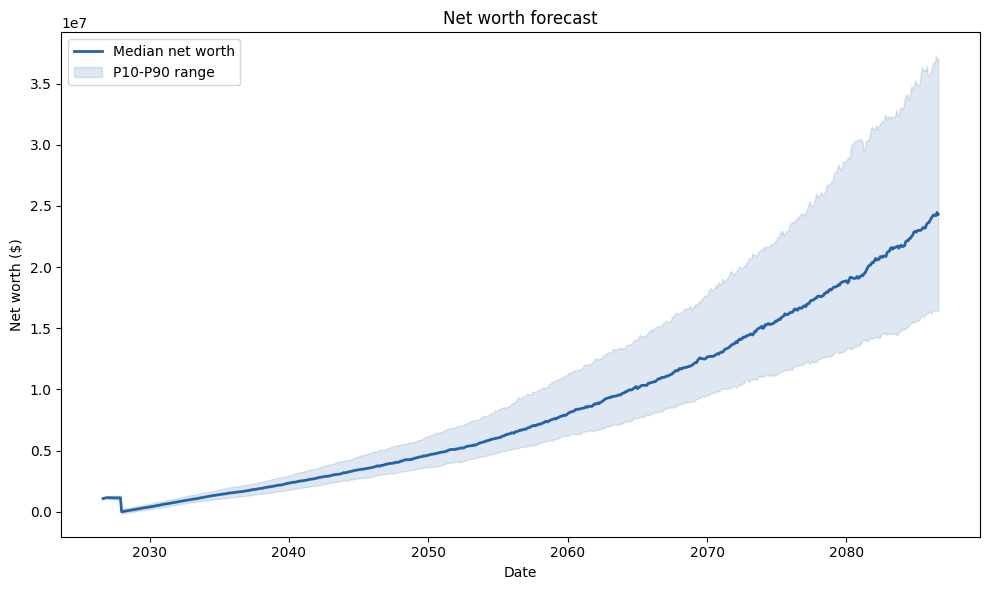

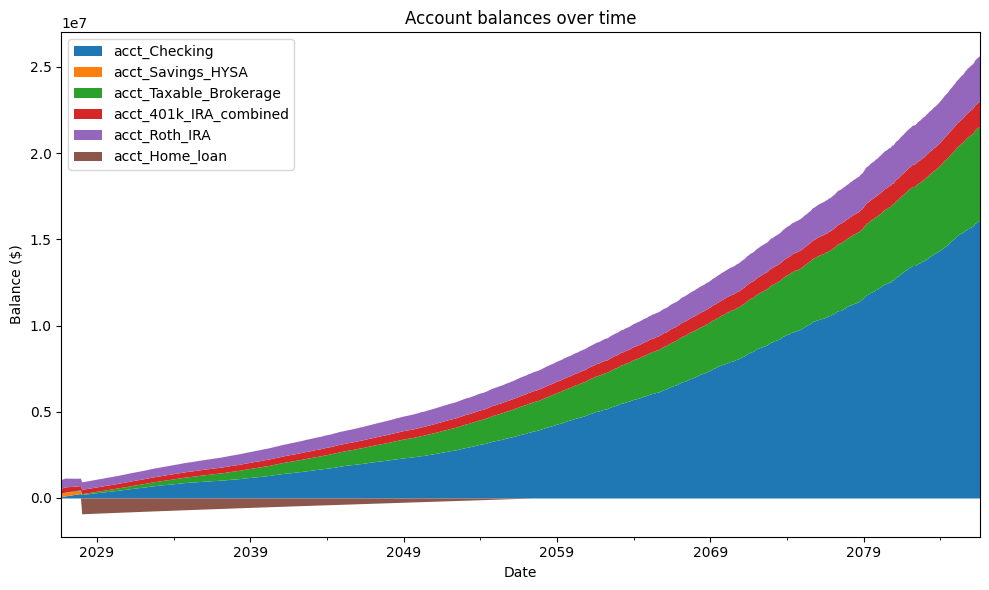

In [3]:
# Paste into a Python REPL / Jupyter cell. Requires: pandas, matplotlib
import base64
import io
import pandas as pd
import matplotlib.pyplot as plt

_csv_b64 = """
...
"""
csv_text = base64.b64decode(_csv_b64.replace("\n", "")).decode("utf-8")
df = pd.read_csv(io.StringIO(csv_text), parse_dates=["month"]).set_index("month")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df["p50"], label="Median net worth", color="#2563a8", linewidth=2)
ax.fill_between(df.index, df["p10"], df["p90"], alpha=0.15, color="#2563a8", label="P10-P90 range")
ax.set_title("Net worth forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Net worth ($)")
ax.legend()
fig.tight_layout()

account_cols = [c for c in df.columns if c.startswith("acct_")]
if account_cols:
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    df[account_cols].plot.area(ax=ax2, linewidth=0)
    ax2.set_title("Account balances over time")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Balance ($)")
    fig2.tight_layout()

plt.show()
